In [129]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
from sklearn.metrics import precision_recall_curve, confusion_matrix, recall_score, precision_score, roc_auc_score



In [130]:
df = pd.read_csv("../data/predicted/train_predicted_xgboost_PHYSICAL_regularization_scale_pos_2860_added_fraud_count_maxdepth4_estimators150_added_added_behaviour_cardswiperatio_merchantstaterisk_2018train_noprev_noitaly.csv", parse_dates=["date"])


In [131]:
df["use_chip"].value_counts()

use_chip
Chip Transaction     663560
Swipe Transaction    157916
Name: count, dtype: int64

In [132]:
def enrich_df_for_analysis(df):
    df_eda = df.copy()

    if "entry_method" not in df_eda.columns:
        df_eda["entry_method"] = df_eda["use_chip"].astype(str).str.replace(" Transaction", "", regex=False)
        
    df_eda["date_dt"] = pd.to_datetime(df_eda["date"])
    
    df_eda = df_eda.sort_values(["card_id", "date_dt"]).reset_index(drop=True)

    df_eda["time_diff_min"] = df_eda.groupby("card_id")["date_dt"].diff().dt.total_seconds() / 60.0
    df_eda["time_diff_min"] = df_eda["time_diff_min"].fillna(0)

    grouped = df_eda.groupby("client_id")["amount"]
    exp_mean = grouped.transform(lambda x: x.shift(1).expanding().mean().fillna(0))
    exp_std = grouped.transform(lambda x: x.shift(1).expanding().std().fillna(0))
    df_eda["user_amount_z_score"] = (df_eda["amount"] - exp_mean) / exp_std.replace(0, 1.0)

    user_col = "client_id" if "client_id" in df_eda.columns else "User"
    df_eda["is_new_mcc"] = (~df_eda.duplicated(subset=[user_col, "mcc"])).astype(int)
    
    is_swipe = (df_eda["entry_method"] == "Swipe").astype(int)
    df_eda["card_swipe_ratio"] = (is_swipe.groupby(df_eda["card_id"]).transform(lambda x: x.shift(1).expanding().mean().fillna(0)))

    df_user_sorted = df_eda.sort_values([user_col, "date_dt"])
    merchant_occurrences = df_user_sorted.groupby([user_col, "merchant_id"]).cumcount()
    df_eda["is_new_merchant"] = (merchant_occurrences == 0).astype(int)

    if "distance_to_home_km" in df_eda.columns:
        df_eda["swipe_distance_km"] = df_eda["distance_to_home_km"] * is_swipe
    if "velocity_km_h" in df_eda.columns:
        df_eda["swipe_velocity_kmh"] = df_eda["velocity_km_h"] * is_swipe

    if "has_chip" in df_eda.columns and "use_chip" in df_eda.columns:
        prev_use = df_eda.groupby("card_id")["use_chip"].shift(1)
        df_eda["is_fallback_attack"] = (
            (df_eda["has_chip"].astype(str).str.upper() == "YES") &
            (df_eda["use_chip"].astype(str).str.lower().str.contains("swipe", na=False)) &
            (prev_use.astype(str).str.lower().str.contains("chip", na=False))
        ).astype(int)

    if "errors" in df_eda.columns:
        errors_lower = df_eda["errors"].fillna("No error").astype(str).str.lower()
        df_eda["has_bad_cvv"] = errors_lower.str.contains("cvv", na=False, case=False).astype(int)
        df_eda["has_bad_pin"] = errors_lower.str.contains("pin", na=False, case=False).astype(int)
        df_eda["has_insufficient_balance"] = errors_lower.str.contains("balance", na=False, case=False).astype(int)
        df_eda["has_technical_glitch"] = errors_lower.str.contains("glitch", na=False, case=False).astype(int)

    df_temp = df_eda.set_index("date_dt")
    df_eda["swipe_count_1h"] = (
        df_temp.groupby("card_id")["amount"]
        .transform(lambda x: x.rolling("1h").count() - 1)
        .fillna(0)
        .values
    ) * is_swipe

    if "errors" in df_eda.columns:
        df_eda["insufficient_balance_count_1h"] = (
            df_temp.groupby("card_id")["has_insufficient_balance"]
            .transform(lambda x: x.rolling("1h").sum() - x)
            .fillna(0)
            .values
        )
        df_eda["bad_cvv_count_1h"] = (
            df_temp.groupby("card_id")["has_bad_cvv"]
            .transform(lambda x: x.rolling("1h").sum() - x)
            .fillna(0)
            .values
        )
        df_eda["bad_pin_count_1h"] = (
            df_temp.groupby("card_id")["has_bad_pin"]
            .transform(lambda x: x.rolling("1h").sum() - x)
            .fillna(0)
            .values
        )
        df_eda["tech_glitch_count_1h"] = (
            df_temp.groupby("card_id")["has_technical_glitch"]
            .transform(lambda x: x.rolling("1h").sum() - x)
            .fillna(0)
            .values
        )

    return df_eda

In [133]:
df = enrich_df_for_analysis(df)

In [134]:
df

,date,id,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,velocity_km_h,distance_z_score,predicted_prob,entry_method,date_dt,time_diff_min,swipe_distance_km,swipe_velocity_kmh,is_fallback_attack,swipe_count_1h
0,2018-01-02 07:04:00,20610404,1362,0,70.00,Chip Transaction,61195,Burke,VA,22015.0,...,0.000000,0.000000,NaN,Chip,2018-01-02 07:04:00,0.0,0.0,0.0,0,0.0
1,2018-01-02 07:21:00,20610471,1362,0,90.80,Chip Transaction,61195,Burke,VA,22015.0,...,0.000000,0.000000,NaN,Chip,2018-01-02 07:21:00,17.0,0.0,0.0,0,0.0
2,2018-01-03 10:04:00,20615792,1362,0,22.12,Chip Transaction,81185,Burke,VA,22015.0,...,0.000000,0.000000,NaN,Chip,2018-01-03 10:04:00,1603.0,0.0,0.0,0,0.0
3,2018-01-03 11:19:00,20616217,1362,0,11.43,Chip Transaction,45926,Burke,VA,22015.0,...,0.000000,0.000000,NaN,Chip,2018-01-03 11:19:00,75.0,0.0,0.0,0,0.0
4,2018-01-05 07:19:00,20624546,1362,0,-80.00,Chip Transaction,59935,Burke,VA,22015.0,...,0.000000,-0.377964,NaN,Chip,2018-01-05 07:19:00,2640.0,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821471,2018-12-26 08:14:00,22299145,1115,6138,43.04,Chip Transaction,81833,Tyler,TX,75707.0,...,21.735794,-0.244616,0.004703,Chip,2018-12-26 08:14:00,56.0,0.0,0.0,0,0.0
821472,2018-12-28 07:40:00,22308612,1115,6138,98.00,Chip Transaction,61195,Tyler,TX,75709.0,...,0.401876,-0.253565,0.007564,Chip,2018-12-28 07:40:00,2846.0,0.0,0.0,0,0.0
821473,2018-12-28 07:45:00,22308644,1115,6138,5.72,Chip Transaction,61195,Tyler,TX,75709.0,...,0.000000,-0.253395,0.005710,Chip,2018-12-28 07:45:00,5.0,0.0,0.0,0,0.0
821474,2018-12-28 07:57:00,22308722,1115,6138,-98.00,Chip Transaction,61195,Tyler,TX,75709.0,...,0.000000,-0.253225,0.000710,Chip,2018-12-28 07:57:00,12.0,0.0,0.0,0,0.0


In [135]:
mapping = {True:"Yes", False:"No"}
df["predicted_class"] = df["predicted_prob"]>0.5
df["predicted_class"] = df["predicted_class"].map(mapping)

In [136]:
incorrect_classified = df[df["target"]!=df["predicted_class"]]
correct_classified = df[df["target"]==df["predicted_class"]]
print("Incorrect:", incorrect_classified.shape[0])
print("Correct:", correct_classified.shape[0])

Incorrect: 55347
Correct: 766129


In [137]:
incorrect_with_high_probability_fp = incorrect_classified[incorrect_classified["predicted_prob"]>0.5]
incorrect_with_high_probability_fn = incorrect_classified[incorrect_classified["predicted_prob"]<0.1]
correct_classified_tn = correct_classified[correct_classified["predicted_prob"]<0.5]
correct_classified_tp = correct_classified[correct_classified["predicted_prob"]>0.5]

print("False negatives", incorrect_with_high_probability_fn.shape[0])
print("False positives", incorrect_with_high_probability_fp.shape[0])

False negatives 165
False positives 54667


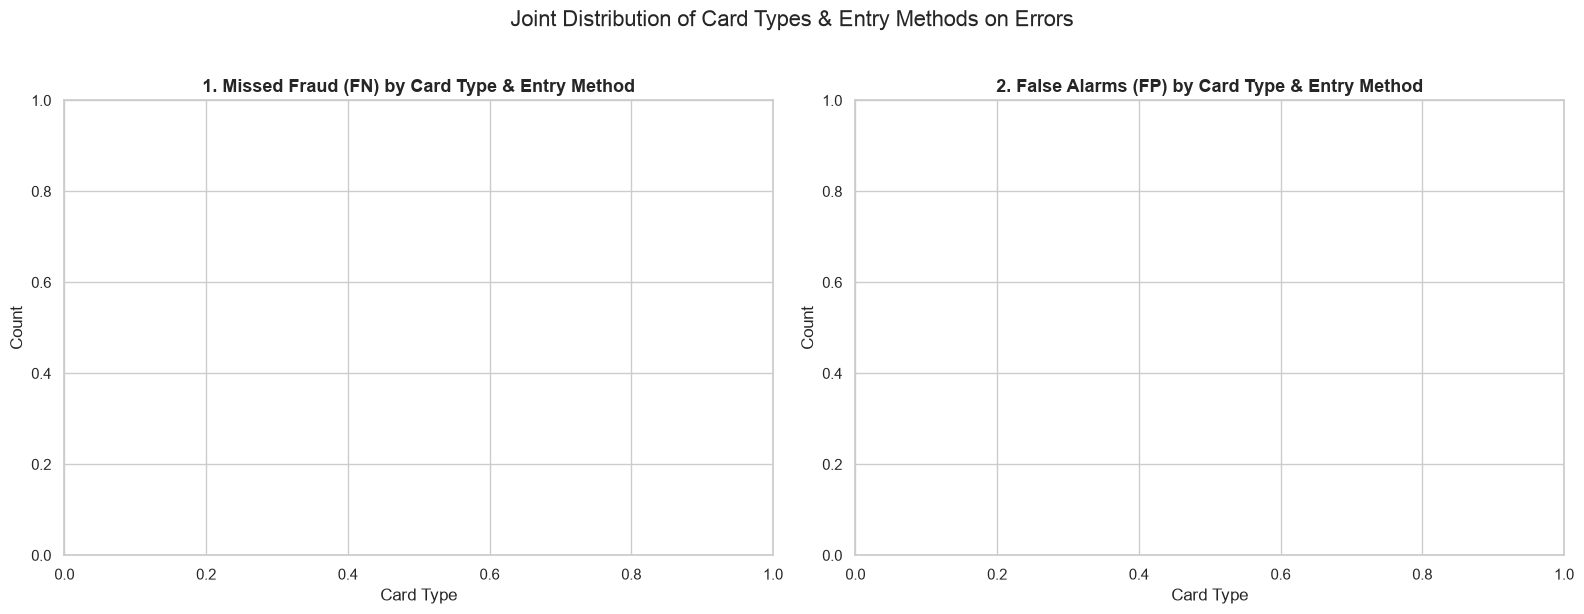

In [138]:
false_negatives = incorrect_classified[(incorrect_classified["predicted_class"]==0 )& (incorrect_classified["target"]=="Yes")]
false_positives = incorrect_classified[(incorrect_classified["predicted_class"]==1 )& (incorrect_classified["target"]=="No")]
fn_physical = false_negatives[false_negatives["entry_method"].isin(["Swipe", "Chip"])]
fp_physical = false_positives[false_positives["entry_method"].isin(["Swipe", "Chip"])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=fn_physical,
    x="card_type",
    hue="entry_method",
    palette="Oranges_r",
    ax=axes[0]
)
axes[0].set_title("1. Missed Fraud (FN) by Card Type & Entry Method", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Card Type")
axes[0].set_ylabel("Count")

sns.countplot(
    data=fp_physical,
    x="card_type",
    hue="entry_method",
    palette="Blues_r",
    ax=axes[1]
)
axes[1].set_title("2. False Alarms (FP) by Card Type & Entry Method", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Card Type")
axes[1].set_ylabel("Count")

plt.suptitle("Joint Distribution of Card Types & Entry Methods on Errors", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

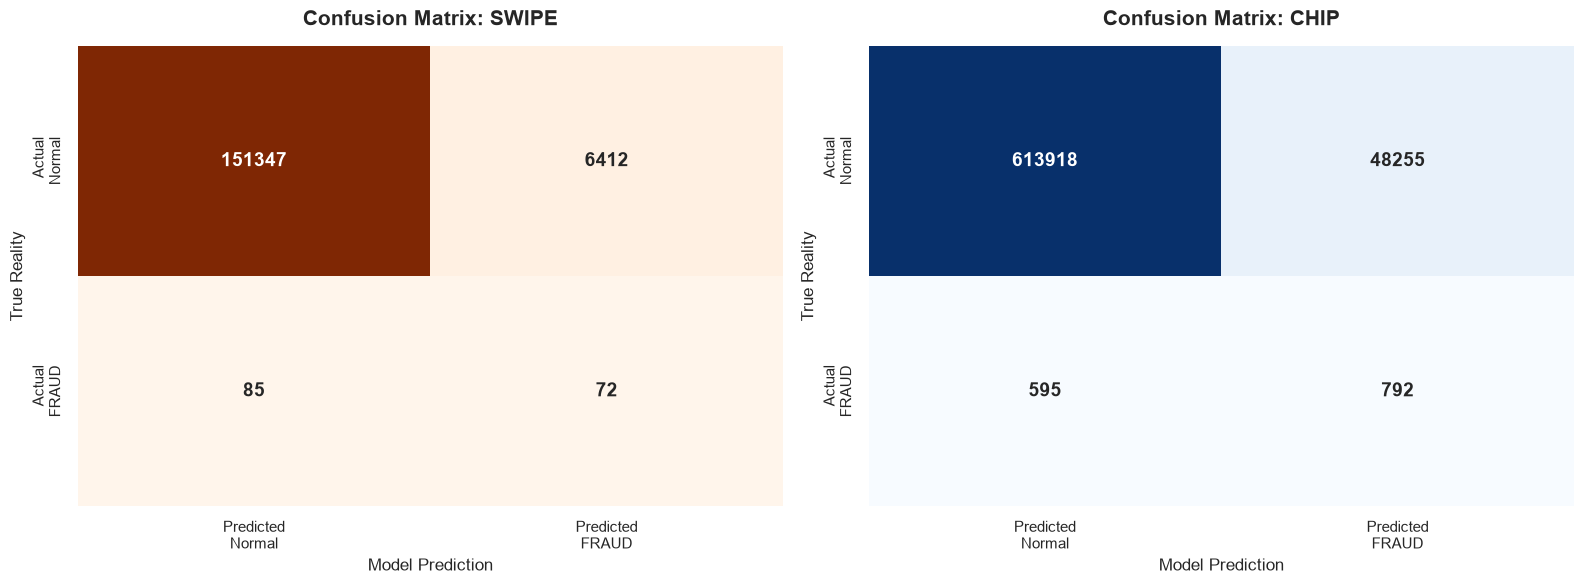

In [139]:



df_cm = df.copy()
if df_cm["target"].dtype != "object":
    df_cm["target"] = df_cm["target"].map({1: "Yes", 0: "No"})
else:
    df_cm["target"] = df_cm["target"]

if "entry_method" not in df_cm.columns:
    df_cm["entry_method"] = df_cm["use_chip"].astype(str).str.replace(" Transaction", "", regex=False)

swipe_df = df_cm[df_cm["entry_method"] == "Swipe"]
chip_df = df_cm[df_cm["entry_method"] == "Chip"]

labels = ["No", "Yes"]
cm_swipe = confusion_matrix(swipe_df["target"], swipe_df["predicted_class"], labels=labels)
cm_chip = confusion_matrix(chip_df["target"], chip_df["predicted_class"], labels=labels)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_tick_labels = ["Predicted\nNormal", "Predicted\nFRAUD"]
y_tick_labels = ["Actual\nNormal", "Actual\nFRAUD"]

sns.heatmap(
    cm_swipe, annot=True, fmt="d", cmap="Oranges", cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=x_tick_labels, yticklabels=y_tick_labels, ax=axes[0]
)
axes[0].set_title("Confusion Matrix: SWIPE", fontsize=15, fontweight="bold", pad=15)
axes[0].set_xlabel("Model Prediction", fontsize=12)
axes[0].set_ylabel("True Reality", fontsize=12)

sns.heatmap(
    cm_chip, annot=True, fmt="d", cmap="Blues", cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=x_tick_labels, yticklabels=y_tick_labels, ax=axes[1]
)
axes[1].set_title("Confusion Matrix: CHIP", fontsize=15, fontweight="bold", pad=15)
axes[1].set_xlabel("Model Prediction", fontsize=12)
axes[1].set_ylabel("True Reality", fontsize=12)

plt.tight_layout()
plt.show()

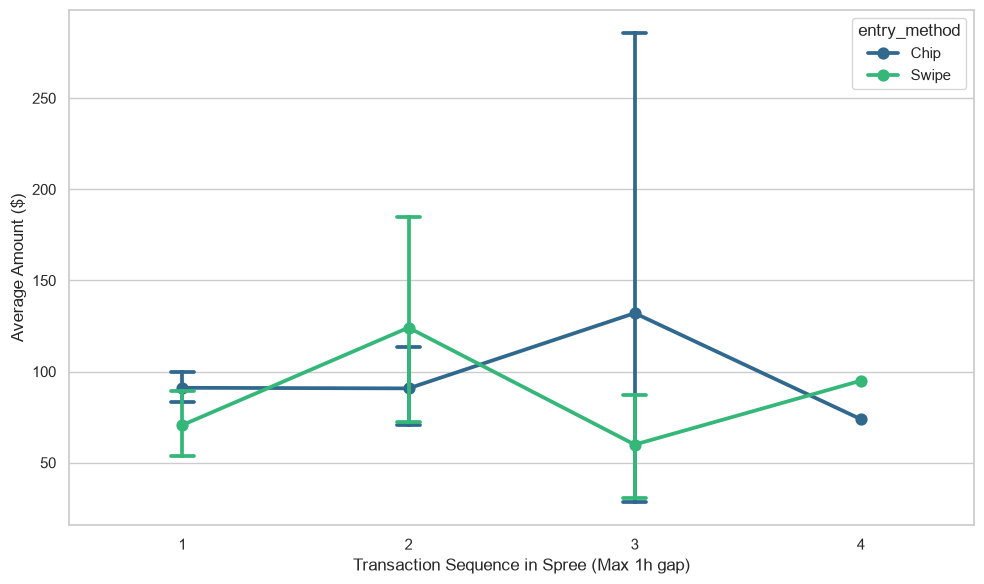

In [140]:


df_fraud = df[df["target"].astype(str).str.lower().str.strip() == "yes"].copy()

df_fraud["amount"] = pd.to_numeric(df_fraud["amount"].astype(str).str.replace(r'[^\d.]', '', regex=True), errors="coerce")
df_fraud = df_fraud.sort_values(["card_id", "date"])

df_fraud["time_diff_min"] = df_fraud.groupby("card_id")["date"].diff().dt.total_seconds() / 60.0
is_new_spree = (df_fraud["time_diff_min"].isna()) | (df_fraud["time_diff_min"] > 60.0)
df_fraud["spree_id"] = is_new_spree.cumsum()
df_fraud["seq_in_spree"] = df_fraud.groupby("spree_id").cumcount() + 1

df_plot = df_fraud[df_fraud["seq_in_spree"] <= 6].copy()
df_plot["entry_method"] = np.where(df_plot["use_chip"].astype(str).str.lower().str.contains("swipe"), "Swipe", "Chip")

plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df_plot,
    x="seq_in_spree",
    y="amount",
    hue="entry_method",
    palette="viridis",
    errorbar="ci",
    capsize=0.1
)
plt.xlabel("Transaction Sequence in Spree (Max 1h gap)")
plt.ylabel("Average Amount ($)")
plt.tight_layout()
plt.show()

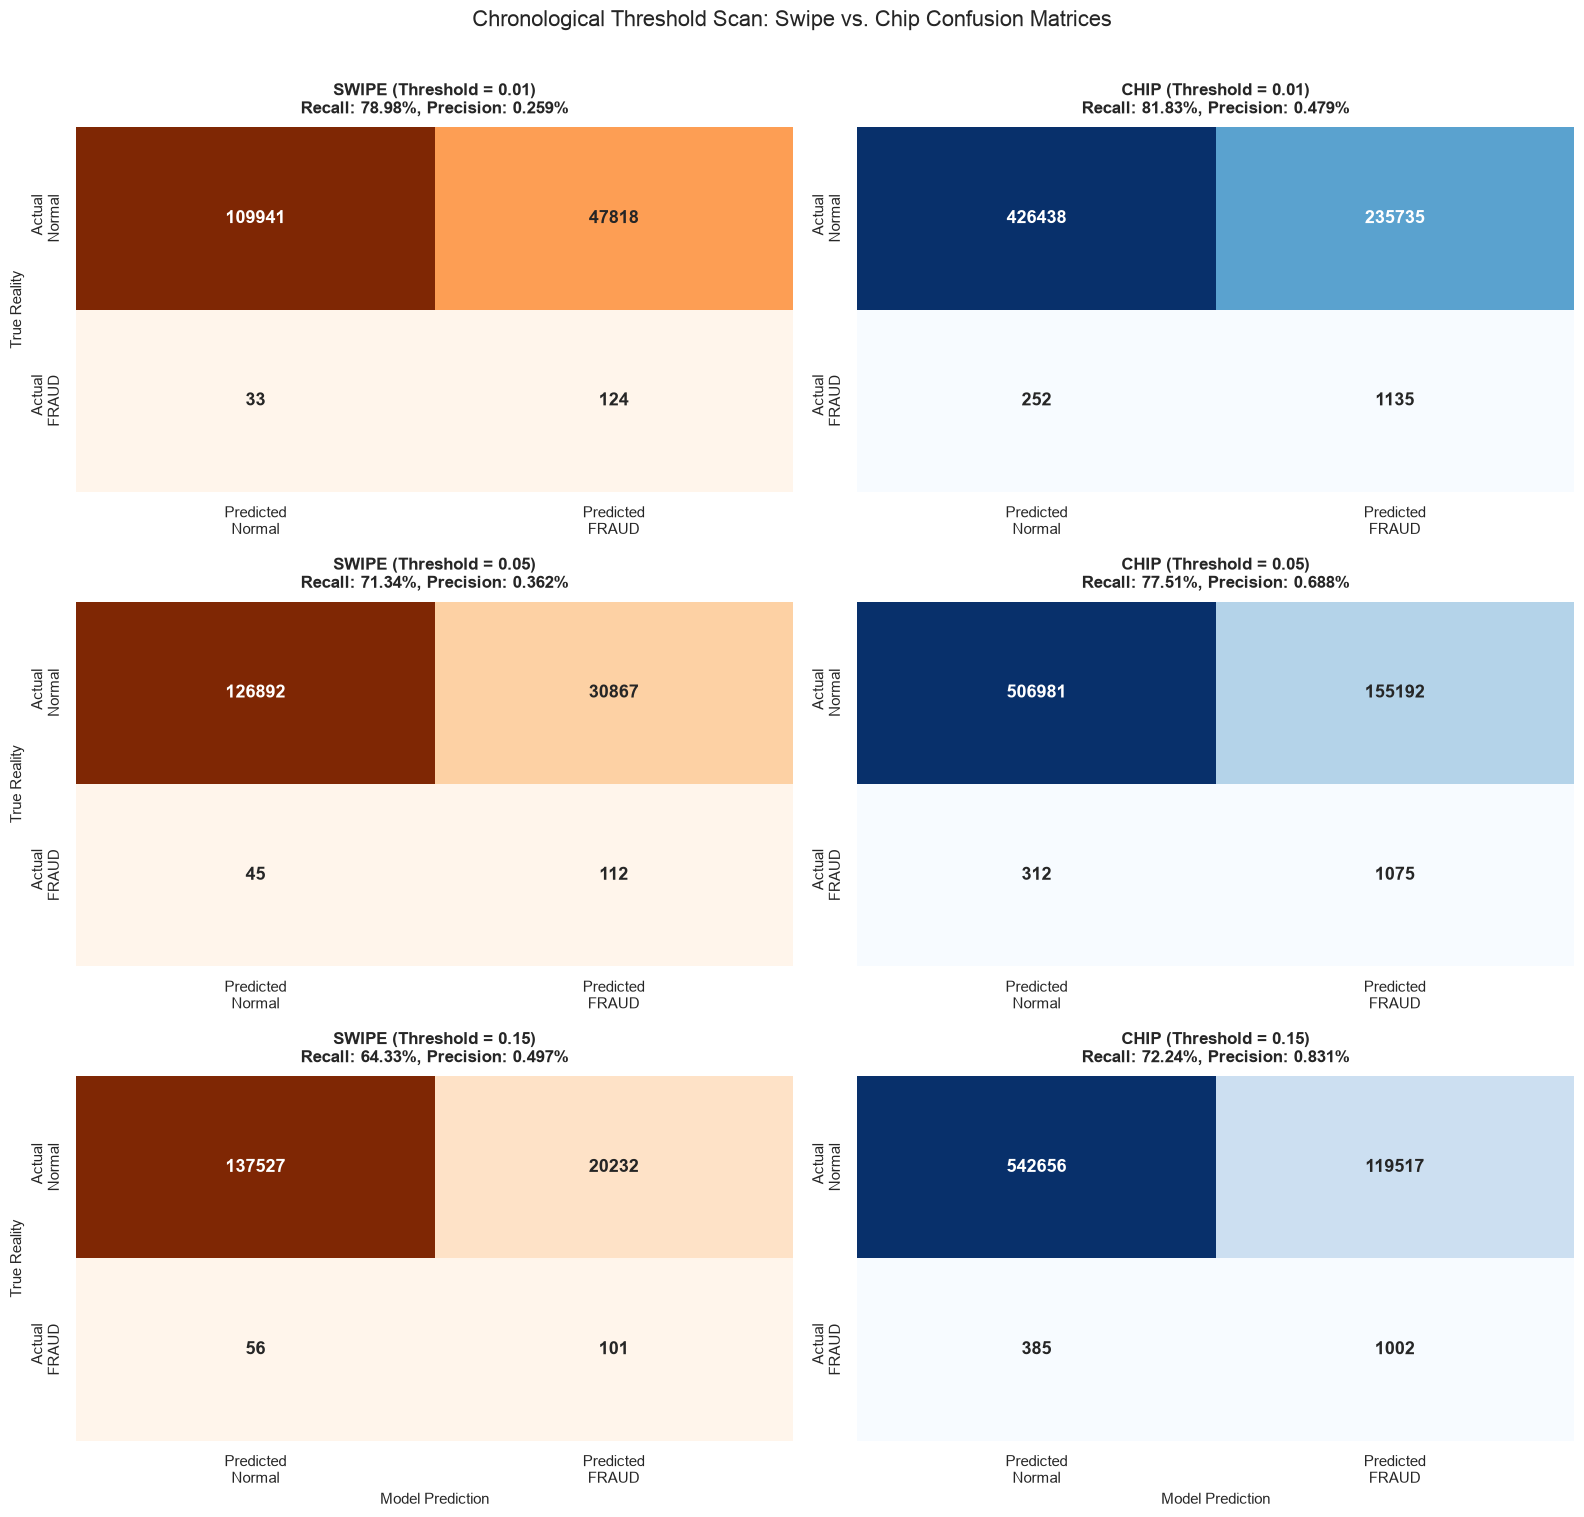

In [141]:

thresholds = [0.01, 0.05, 0.15]

df_cm = df.copy()

if df_cm["target"].dtype != "object":
    df_cm["target"] = df_cm["target"].map({1: "Yes", 0: "No"})
else:
    df_cm["target"] = df_cm["target"]

if "entry_method" not in df_cm.columns:
    df_cm["entry_method"] = df_cm["use_chip"].astype(str).str.replace(" Transaction", "", regex=False)

swipe_df = df_cm[df_cm["entry_method"] == "Swipe"]
chip_df = df_cm[df_cm["entry_method"] == "Chip"]

n_rows = len(thresholds)
sns.set_theme(style="white") 

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))

if n_rows == 1:
    axes = np.array([axes])

labels = ["No", "Yes"]
x_tick_labels = ["Predicted\nNormal", "Predicted\nFRAUD"]
y_tick_labels = ["Actual\nNormal", "Actual\nFRAUD"]

for i, t in enumerate(thresholds):
    swipe_preds_bin = (swipe_df["predicted_prob"] >= t).astype(int).map({1: "Yes", 0: "No"})
    chip_preds_bin = (chip_df["predicted_prob"] >= t).astype(int).map({1: "Yes", 0: "No"})
    
    cm_swipe = confusion_matrix(swipe_df["target"], swipe_preds_bin, labels=labels)
    cm_chip = confusion_matrix(chip_df["target"], chip_preds_bin, labels=labels)
    
    y_swipe_true = (swipe_df["target"] == "Yes").astype(int)
    y_swipe_pred = (swipe_df["predicted_prob"] >= t).astype(int)
    swipe_rec = recall_score(y_swipe_true, y_swipe_pred, zero_division=0)
    swipe_prec = precision_score(y_swipe_true, y_swipe_pred, zero_division=0)

    y_chip_true = (chip_df["target"] == "Yes").astype(int)
    y_chip_pred = (chip_df["predicted_prob"] >= t).astype(int)
    chip_rec = recall_score(y_chip_true, y_chip_pred, zero_division=0)
    chip_prec = precision_score(y_chip_true, y_chip_pred, zero_division=0)

    sns.heatmap(cm_swipe, annot=True, fmt="d", cmap="Oranges", cbar=False,annot_kws={"size": 13, "weight": "bold"},xticklabels=x_tick_labels, yticklabels=y_tick_labels, ax=axes[i, 0])
    axes[i, 0].set_title(f"SWIPE (Threshold = {t:.2f})\nRecall: {swipe_rec:.2%}, Precision: {swipe_prec:.3%}", 
                         fontsize=12, fontweight="bold", pad=10)
    axes[i, 0].set_ylabel("True Reality", fontsize=11)
    if i == n_rows - 1:
         axes[i, 0].set_xlabel("Model Prediction", fontsize=11)

    sns.heatmap(cm_chip, annot=True, fmt="d", cmap="Blues", cbar=False,annot_kws={"size": 13, "weight": "bold"},xticklabels=x_tick_labels, yticklabels=y_tick_labels, ax=axes[i, 1])
    axes[i, 1].set_title(f"CHIP (Threshold = {t:.2f})\nRecall: {chip_rec:.2%}, Precision: {chip_prec:.3%}", 
                         fontsize=12, fontweight="bold", pad=10)
    if i == n_rows - 1:
        axes[i, 1].set_xlabel("Model Prediction", fontsize=11)

plt.suptitle("Chronological Threshold Scan: Swipe vs. Chip Confusion Matrices", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

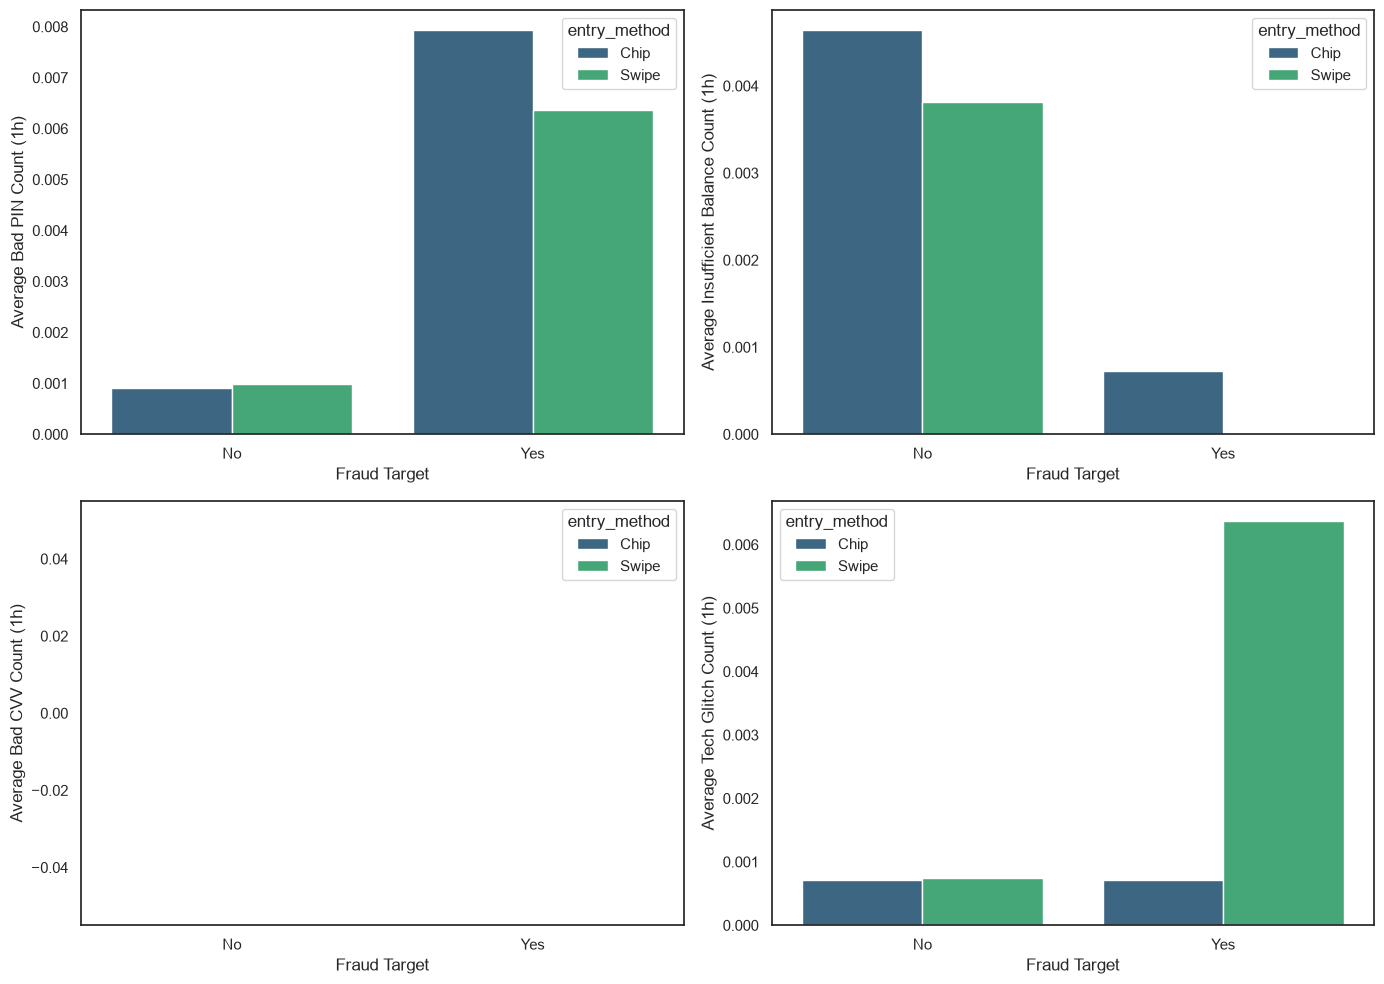

In [142]:


df_clean = df.copy()
df_clean["entry_method"] = np.where(df_clean["use_chip"].astype(str).str.lower().str.contains("swipe", na=False), "Swipe", "Chip")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(
    data=df_clean,
    x="target",
    y="bad_pin_count_1h",
    hue="entry_method",
    palette="viridis",
    errorbar=None,
    ax=axes[0, 0]
)
axes[0, 0].set_xlabel("Fraud Target")
axes[0, 0].set_ylabel("Average Bad PIN Count (1h)")

sns.barplot(
    data=df_clean,
    x="target",
    y="insufficient_balance_count_1h",
    hue="entry_method",
    palette="viridis",
    errorbar=None,
    ax=axes[0, 1]
)
axes[0, 1].set_xlabel("Fraud Target")
axes[0, 1].set_ylabel("Average Insufficient Balance Count (1h)")

sns.barplot(
    data=df_clean,
    x="target",
    y="bad_cvv_count_1h",
    hue="entry_method",
    palette="viridis",
    errorbar=None,
    ax=axes[1, 0]
)
axes[1, 0].set_xlabel("Fraud Target")
axes[1, 0].set_ylabel("Average Bad CVV Count (1h)")

sns.barplot(
    data=df_clean,
    x="target",
    y="tech_glitch_count_1h",
    hue="entry_method",
    palette="viridis",
    errorbar=None,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel("Fraud Target")
axes[1, 1].set_ylabel("Average Tech Glitch Count (1h)")

plt.tight_layout()
plt.show()

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_61701/1349310610.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_61701/1349310610.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(title="Model Outcome")


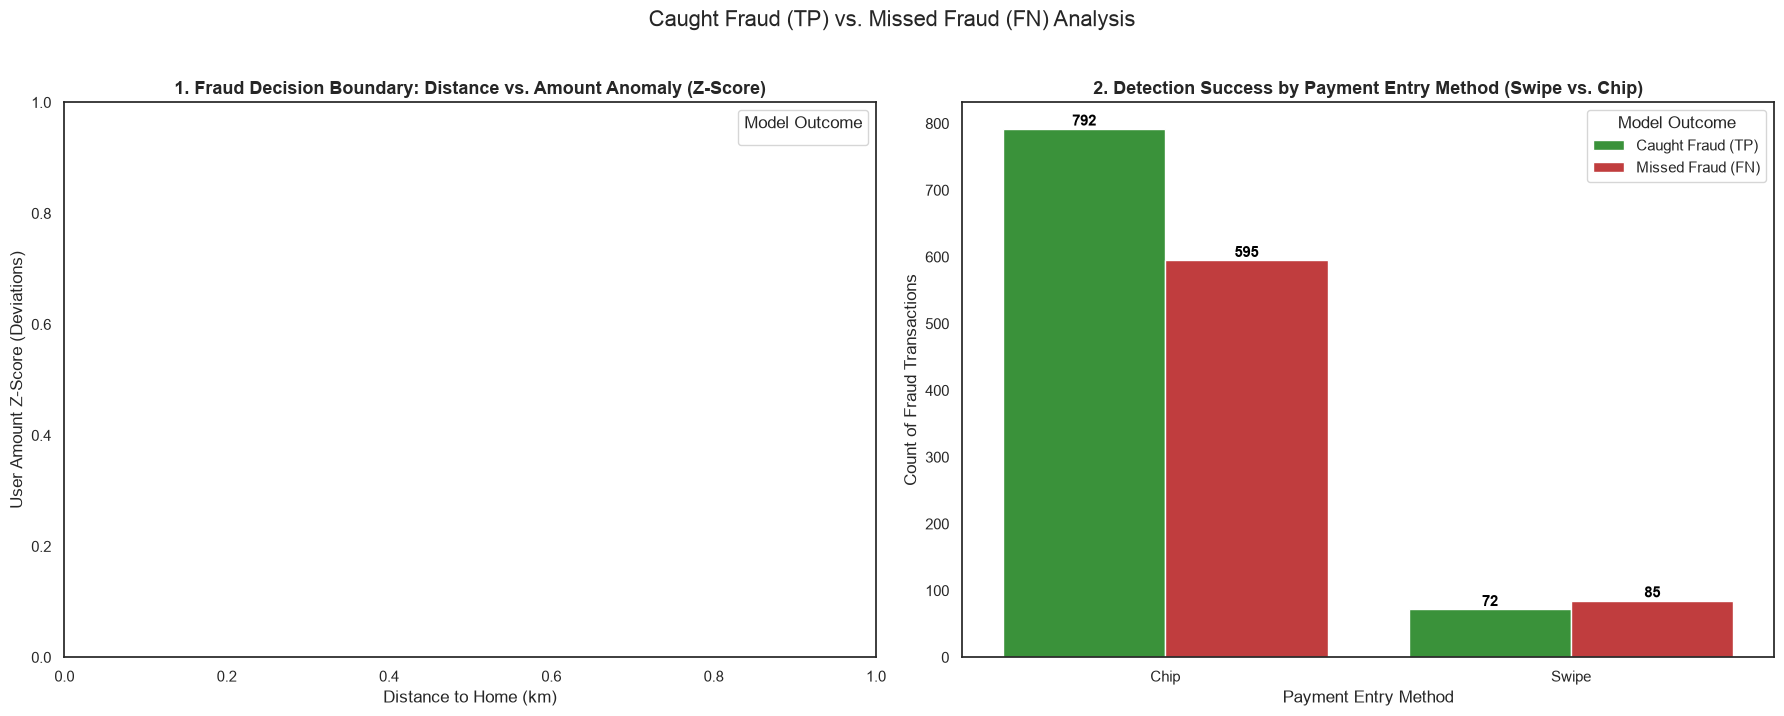

In [143]:

fraud_only = df[df["target"] == "Yes"].copy()

fraud_only["outcome"] = np.where(
    fraud_only["predicted_class"] == "Yes", 
    "Caught Fraud (TP)", 
    "Missed Fraud (FN)"
)

if "entry_method" not in fraud_only.columns:
    fraud_only["entry_method"] = fraud_only["use_chip"].astype(str).str.replace(" Transaction", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))


plot_df = fraud_only[
    fraud_only["distance_to_home_km"].between(0, 200) & 
    fraud_only["user_amount_z_score"].between(-2, 15)
]

sns.scatterplot(
    data=plot_df,
    x="distance_to_home_km",
    y="user_amount_z_score",
    hue="outcome",
    palette={"Caught Fraud (TP)": "#2ca02c", "Missed Fraud (FN)": "#d62728"},
    alpha=0.6,
    s=25, 
    ax=axes[0]
)
axes[0].set_title("1. Fraud Decision Boundary: Distance vs. Amount Anomaly (Z-Score)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Distance to Home (km)")
axes[0].set_ylabel("User Amount Z-Score (Deviations)")
axes[0].legend(title="Model Outcome")


physical_fraud = fraud_only[fraud_only["entry_method"].isin(["Swipe", "Chip"])]

sns.countplot(
    data=physical_fraud,
    x="entry_method",
    hue="outcome",
    palette={"Caught Fraud (TP)": "#2ca02c", "Missed Fraud (FN)": "#d62728"},
    ax=axes[1]
)
axes[1].set_title("2. Detection Success by Payment Entry Method (Swipe vs. Chip)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Payment Entry Method")
axes[1].set_ylabel("Count of Fraud Transactions")
axes[1].legend(title="Model Outcome")

for p in axes[1].patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

plt.suptitle("Caught Fraud (TP) vs. Missed Fraud (FN) Analysis", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

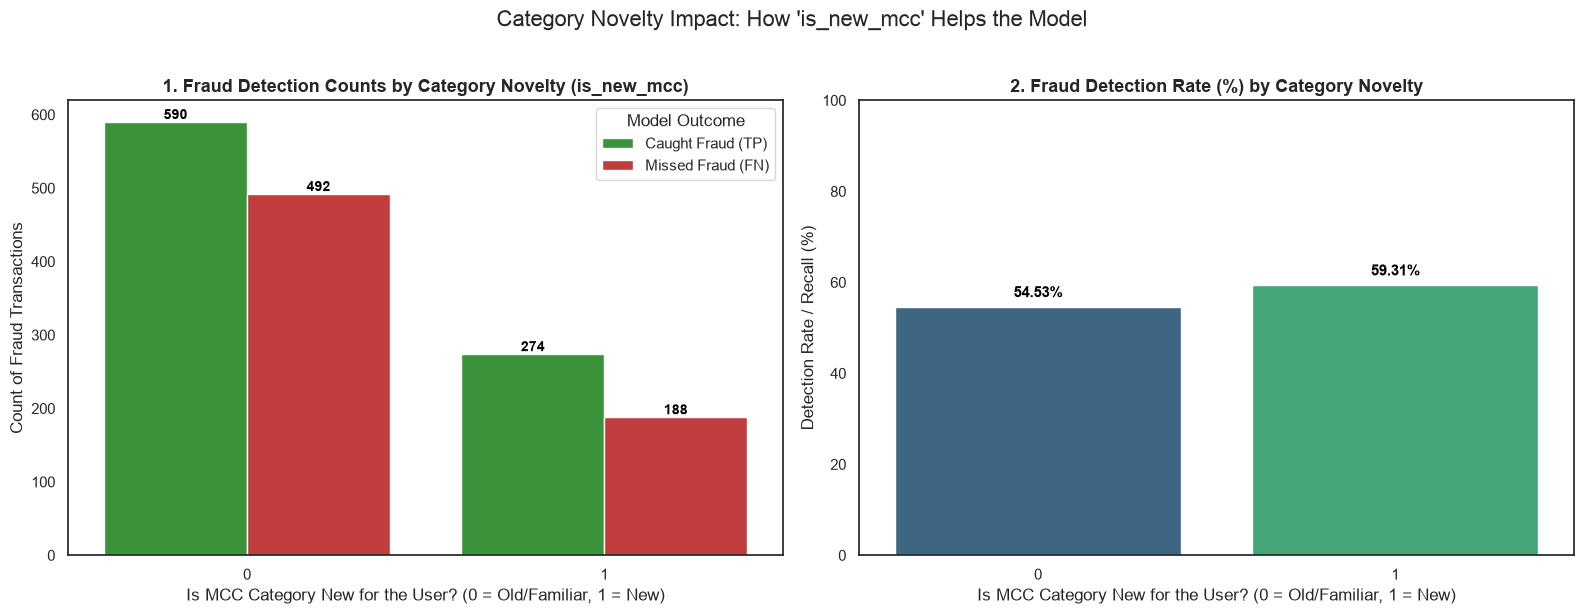

In [144]:


df_plot = df.copy()

df_plot = df_plot.sort_values(["card_id", "date"]).reset_index(drop=True)

user_col = "client_id" if "client_id" in df_plot.columns else ("User" if "User" in df_plot.columns else None)

if "is_new_mcc" not in df_plot.columns and user_col is not None:
    df_plot["is_new_mcc"] = (~df_plot.duplicated(subset=[user_col, "mcc"])).astype(int)

fraud_only = df_plot[df_plot["target"] == "Yes"].copy()

fraud_only["outcome"] = np.where(
    fraud_only["predicted_class"] == "Yes", 
    "Caught Fraud (TP)", 
    "Missed Fraud (FN)"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=fraud_only,
    x="is_new_mcc",
    hue="outcome",
    palette={"Caught Fraud (TP)": "#2ca02c", "Missed Fraud (FN)": "#d62728"}, 
    ax=axes[0]
)
axes[0].set_title("1. Fraud Detection Counts by Category Novelty (is_new_mcc)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Is MCC Category New for the User? (0 = Old/Familiar, 1 = New)")
axes[0].set_ylabel("Count of Fraud Transactions")
axes[0].legend(title="Model Outcome")

for p in axes[0].patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')


detection_rates = fraud_only.groupby("is_new_mcc")["outcome"].apply(
    lambda x: (x == "Caught Fraud (TP)").mean() * 100
).reset_index(name="detection_rate")

sns.barplot(
    data=detection_rates,
    x="is_new_mcc",
    y="detection_rate",
    palette="viridis",
    hue="is_new_mcc",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("2. Fraud Detection Rate (%) by Category Novelty", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Is MCC Category New for the User? (0 = Old/Familiar, 1 = New)")
axes[1].set_ylabel("Detection Rate / Recall (%)")
axes[1].set_ylim(0, 100)

for p in axes[1].patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        axes[1].annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height + 1.5),
                    ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

plt.suptitle("Category Novelty Impact: How 'is_new_mcc' Helps the Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

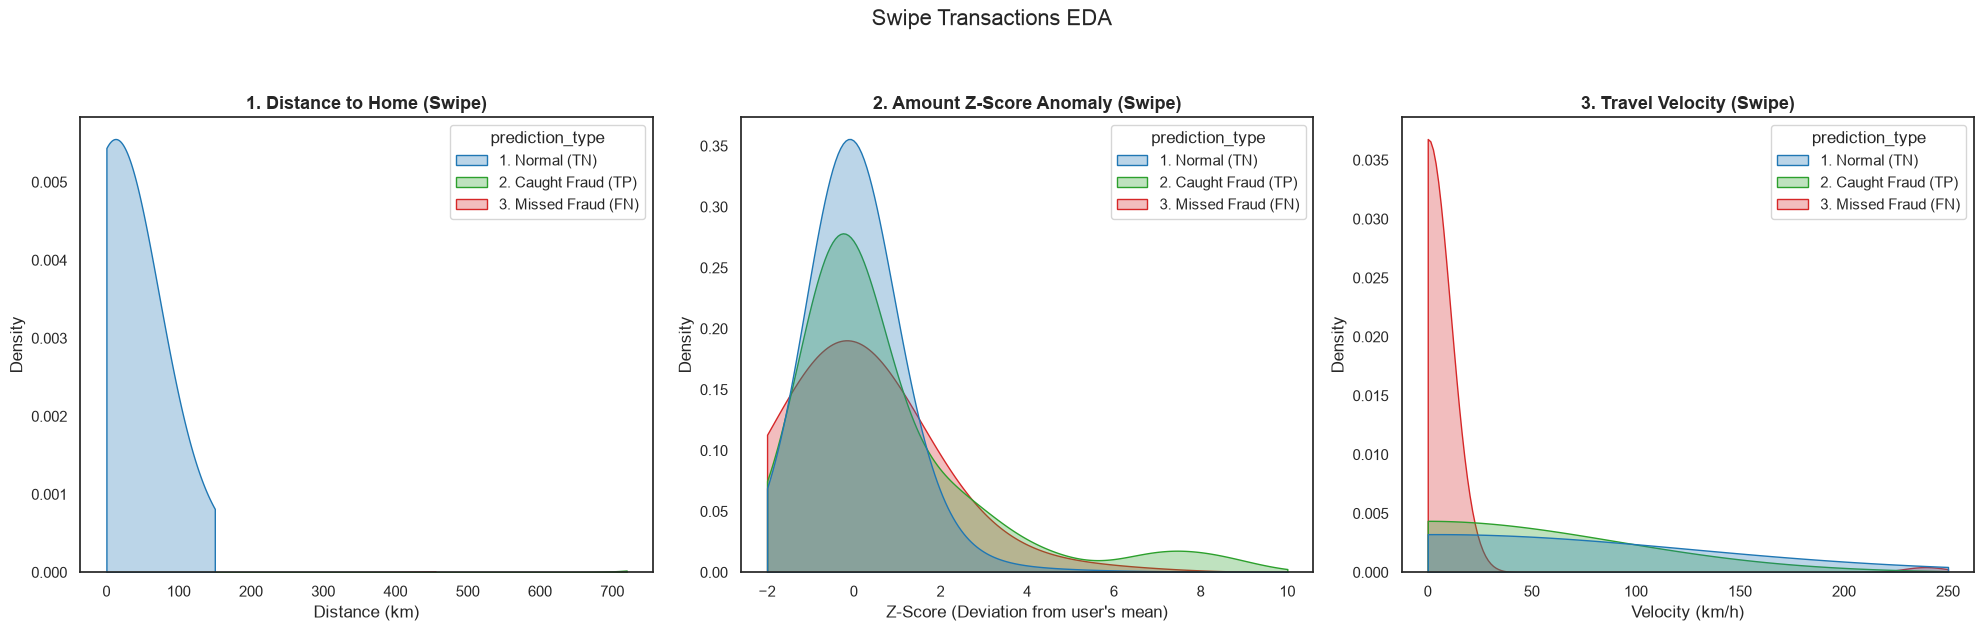

In [145]:


swipe_df = df[df["use_chip"] == "Swipe Transaction"].copy()


conditions = [
    (swipe_df['target'] == 'No')  & (swipe_df['predicted_class'] == 'No'),  
    (swipe_df['target'] == 'Yes') & (swipe_df['predicted_class'] == 'Yes'),  
    (swipe_df['target'] == 'Yes') & (swipe_df['predicted_class'] == 'No')   
]
choices = ['1. Normal (TN)', '2. Caught Fraud (TP)', '3. Missed Fraud (FN)']

swipe_df['prediction_type'] = np.select(conditions, choices, default='Other (FP)')

plot_df = swipe_df[swipe_df['prediction_type'].isin(choices)]

palette = {'1. Normal (TN)': '#1f77b4', '2. Caught Fraud (TP)': '#2ca02c', '3. Missed Fraud (FN)': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

if "distance_to_home_km" in plot_df.columns:
    sns.kdeplot(data=plot_df, x="distance_to_home_km", hue="prediction_type", fill=True, common_norm=False, palette=palette, alpha=0.3, clip=(0, 150), ax=axes[0])
axes[0].set_title("1. Distance to Home (Swipe)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Distance (km)")

if "user_amount_z_score" in plot_df.columns:
    sns.kdeplot(data=plot_df, x="user_amount_z_score", hue="prediction_type", fill=True, common_norm=False, palette=palette, alpha=0.3, clip=(-2, 10), ax=axes[1])
axes[1].set_title("2. Amount Z-Score Anomaly (Swipe)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Z-Score (Deviation from user's mean)")


if "velocity_km_h" in plot_df.columns:
    sns.kdeplot(data=plot_df, x="velocity_km_h", hue="prediction_type", fill=True, common_norm=False, palette=palette, alpha=0.3, clip=(0, 250), ax=axes[2])
    axes[2].set_title("3. Travel Velocity (Swipe)", fontsize=13, fontweight='bold')
    axes[2].set_xlabel("Velocity (km/h)")
    
elif "time_diff_min" in plot_df.columns:
    sns.kdeplot(data=plot_df, x="time_diff_min", hue="prediction_type", fill=True, common_norm=False, palette=palette, alpha=0.3, clip=(0, 300), ax=axes[2] )
    axes[2].set_title("3. Time Since Last Trx (Swipe)", fontsize=13, fontweight='bold')
    axes[2].set_xlabel("Minutes Since Last Trx")

plt.suptitle("Swipe Transactions EDA", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

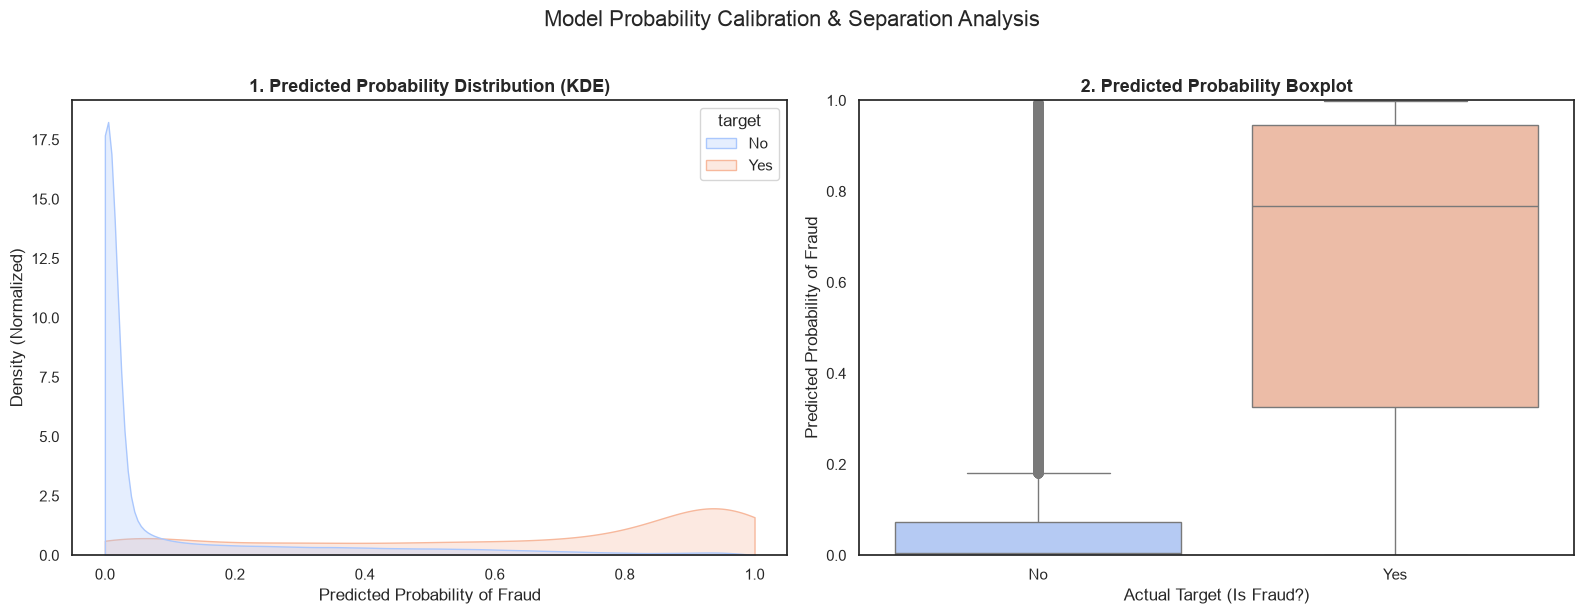

In [146]:


df_plot = df.copy()
if df_plot["target"].dtype != "object":
    df_plot["target"] = df_plot["target"].map({1: "Yes", 0: "No"})
else:
    df_plot["target"] = df_plot["target"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.kdeplot(
    data=df_plot,
    x="predicted_prob",
    hue="target",
    fill=True,
    alpha=0.3,
    palette="coolwarm",
    common_norm=False, 
    clip=(0, 1),        
    ax=axes[0]
)
axes[0].set_title("1. Predicted Probability Distribution (KDE)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Probability of Fraud")
axes[0].set_ylabel("Density (Normalized)")

sns.boxplot(
    data=df_plot,
    x="target",
    y="predicted_prob",
    palette="coolwarm",
    hue="target",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("2. Predicted Probability Boxplot", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Actual Target (Is Fraud?)")
axes[1].set_ylabel("Predicted Probability of Fraud")
axes[1].set_ylim(0, 1) 

plt.suptitle("Model Probability Calibration & Separation Analysis", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

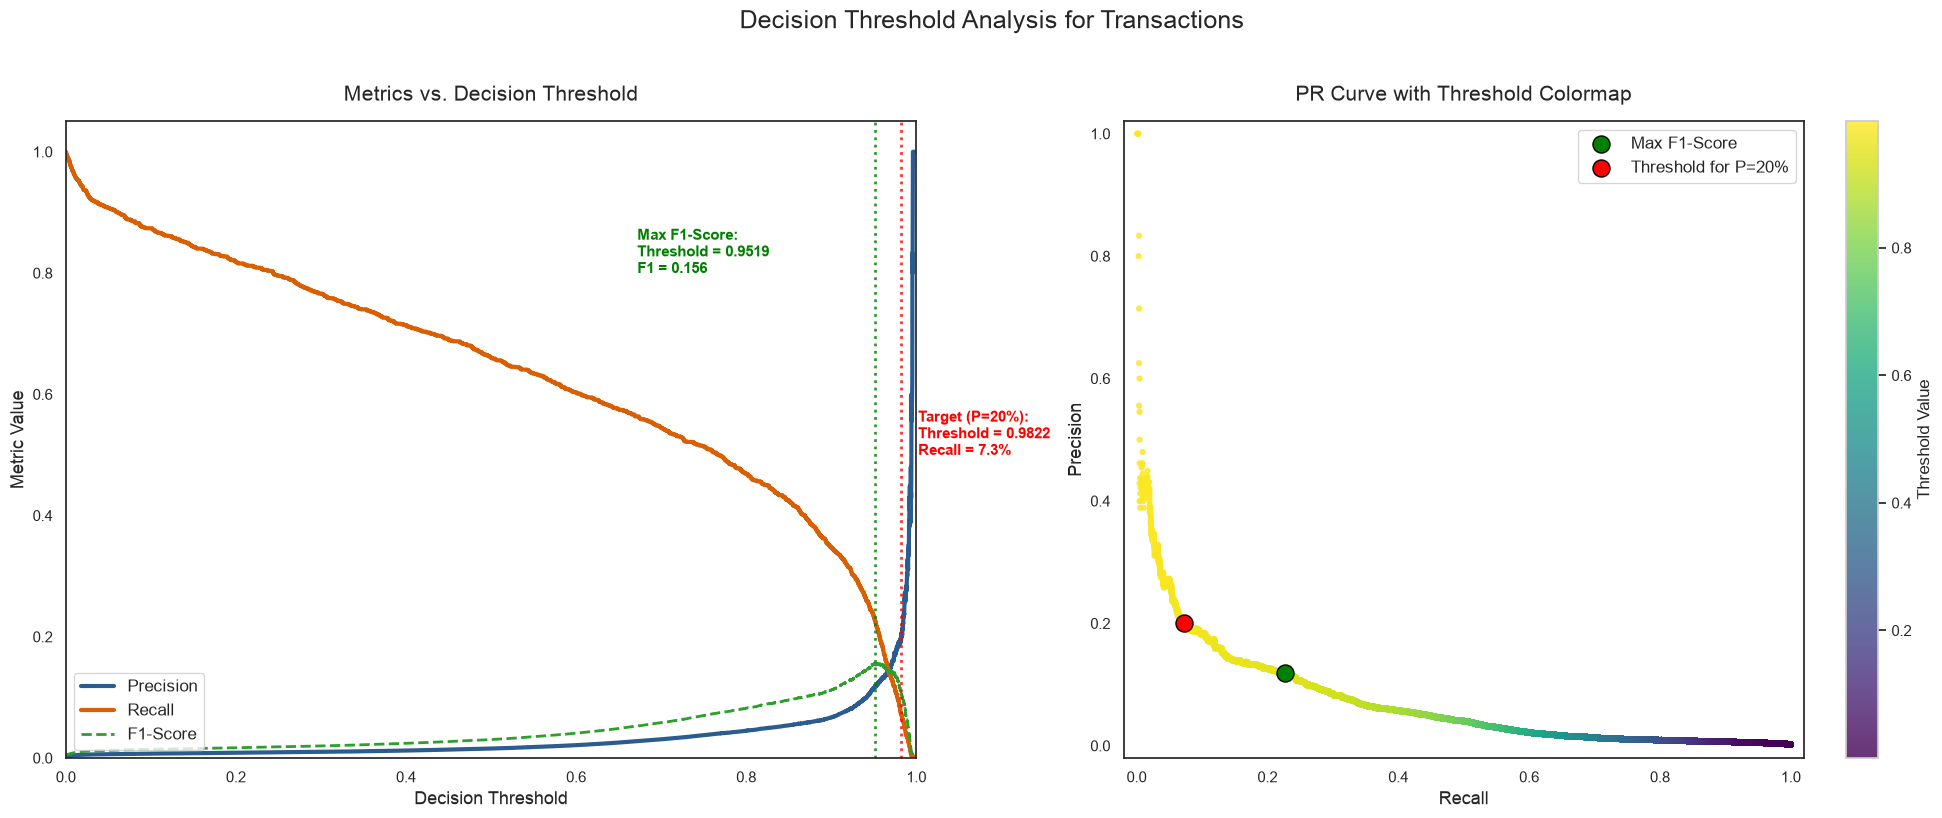

In [147]:


def plot_threshold_analysis(df):
    valid_data = df[['target', 'predicted_prob']].dropna()
    y_true = (valid_data["target"] == "Yes").astype(int)
    y_prob = valid_data["predicted_prob"]
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    p_curve = precisions[:-1]
    r_curve = recalls[:-1]
    f1_curve = f1_scores[:-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.set_theme(style="whitegrid")
    
    ax1 = axes[0]
    ax1.plot(thresholds, p_curve, label="Precision", color="#2b5c8f", lw=3)
    ax1.plot(thresholds, r_curve, label="Recall", color="#d95f02", lw=3)
    ax1.plot(thresholds, f1_curve, label="F1-Score", color="#2ca02c", lw=2, linestyle="--")
    
    best_f1_idx = np.argmax(f1_curve)
    best_thresh_f1 = thresholds[best_f1_idx]
    best_f1_val = f1_curve[best_f1_idx]
    
    target_p = 0.20
    p_target_indices = np.where(p_curve >= target_p)[0]
    if len(p_target_indices) > 0:
        thresh_p_target = thresholds[p_target_indices[0]]
        recall_p_target = r_curve[p_target_indices[0]]
        
        ax1.axvline(x=thresh_p_target, color="red", linestyle=":", alpha=0.8, lw=2)
        ax1.text(thresh_p_target + 0.02, 0.5, f"Target (P={target_p:.0%}):\nThreshold = {thresh_p_target:.4f}\nRecall = {recall_p_target:.1%}", color="red", fontsize=11, weight="bold")
        
    ax1.axvline(x=best_thresh_f1, color="green", linestyle=":", alpha=0.8, lw=2)
    ax1.text(best_thresh_f1 - 0.28, 0.8, f"Max F1-Score:\nThreshold = {best_thresh_f1:.4f}\nF1 = {best_f1_val:.3f}", color="green", fontsize=11, weight="bold")
    
    ax1.set_title("Metrics vs. Decision Threshold", fontsize=15, pad=15)
    ax1.set_xlabel("Decision Threshold", fontsize=13)
    ax1.set_ylabel("Metric Value", fontsize=13)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=12, loc="lower left")
    
    ax2 = axes[1]
    sc = ax2.scatter(r_curve, p_curve, c=thresholds, cmap="viridis", s=12, alpha=0.8)
    
    cbar = plt.colorbar(sc, ax=ax2)
    cbar.set_label("Threshold Value", fontsize=12)
    
    ax2.scatter(recalls[:-1][best_f1_idx], precisions[:-1][best_f1_idx], color="green", s=150, edgecolors="black", zorder=5, label="Max F1-Score")
    if len(p_target_indices) > 0:
        ax2.scatter(recalls[:-1][p_target_indices[0]], precisions[:-1][p_target_indices[0]], color="red", s=150, edgecolors="black", zorder=5, label=f"Threshold for P={target_p:.0%}")
        
    ax2.set_title("PR Curve with Threshold Colormap", fontsize=15, pad=15)
    ax2.set_xlabel("Recall", fontsize=13)
    ax2.set_ylabel("Precision", fontsize=13)
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_ylim(-0.02, 1.02)
    ax2.legend(fontsize=12, loc="upper right")
    
    plt.suptitle("Decision Threshold Analysis for Transactions", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_threshold_analysis(df)

In [148]:
df.groupby('target')['predicted_prob'].median()

target
No     0.005935
Yes    0.767114
Name: predicted_prob, dtype: float64

In [149]:

df_tenure = df.copy()
df_tenure['is_fraud'] = (df_tenure['target'] == 'Yes').astype(int)
df_tenure = df_tenure.sort_values('date')
df_tenure['client_trx_num'] = df_tenure.groupby('client_id').cumcount()

bins = [-1, 10, 50, 200, 1000, 1_000_000]
labels = ['1-10', '11-50', '51-200', '201-1000', '1000+']
df_tenure['tenure_bucket'] = pd.cut(df_tenure['client_trx_num'], bins=bins, labels=labels)

rows = []
for b in labels:
    mask = df_tenure['tenure_bucket'] == b
    n = mask.sum()
    n_fraud = df_tenure.loc[mask, 'is_fraud'].sum()
    new_merchant_rate = df_tenure.loc[mask, 'is_new_merchant'].mean()
    if n > 100 and n_fraud > 5:
        auc = roc_auc_score(df_tenure.loc[mask, 'is_fraud'], df_tenure.loc[mask, 'is_new_merchant'])
        fraud_rate_new = df_tenure.loc[mask & (df_tenure['is_new_merchant'] == 1), 'is_fraud'].mean() * 100
        fraud_rate_old = df_tenure.loc[mask & (df_tenure['is_new_merchant'] == 0), 'is_fraud'].mean() * 100
    else:
        auc, fraud_rate_new, fraud_rate_old = np.nan, np.nan, np.nan
    rows.append({'tenure_bucket': b, 'n': n, 'n_fraud': n_fraud, 'new_merchant_rate': new_merchant_rate,
                 'auc': auc, 'fraud_rate_new_merchant': fraud_rate_new, 'fraud_rate_known_merchant': fraud_rate_old})

tenure_summary = pd.DataFrame(rows)
tenure_summary

,tenure_bucket,n,n_fraud,new_merchant_rate,auc,fraud_rate_new_merchant,fraud_rate_known_merchant
0,1-10,13278,25,0.699955,0.630268,0.258231,0.025100
1,11-50,48280,77,0.334321,0.768333,0.415092,0.031115
2,51-200,180563,459,0.135581,0.807719,1.405171,0.073679
3,201-1000,530782,930,0.062918,0.813714,1.919392,0.058104
4,1000+,48573,53,0.027340,0.779087,2.334337,0.046566


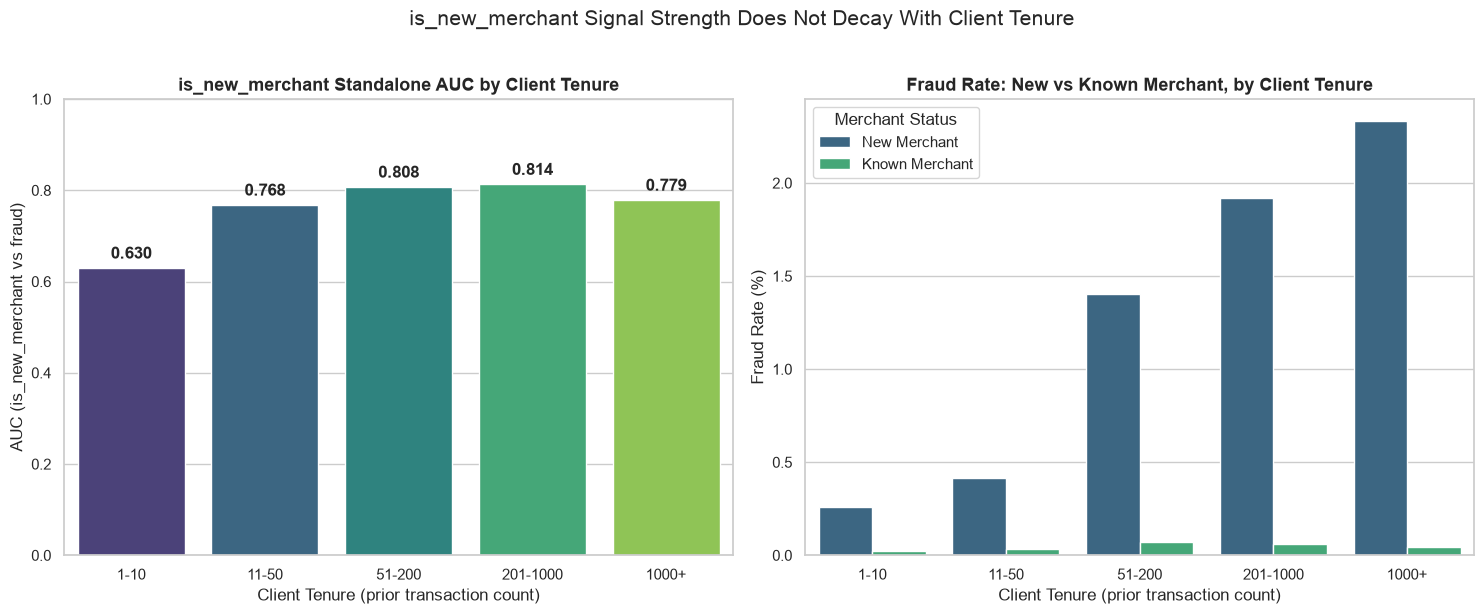

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=tenure_summary, x='tenure_bucket', y='auc', hue='tenure_bucket',
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('is_new_merchant Standalone AUC by Client Tenure', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Client Tenure (prior transaction count)')
axes[0].set_ylabel('AUC (is_new_merchant vs fraud)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(tenure_summary['auc']):
    if pd.notna(v):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plot_df = tenure_summary.melt(id_vars='tenure_bucket',
                               value_vars=['fraud_rate_new_merchant', 'fraud_rate_known_merchant'],
                               var_name='merchant_status', value_name='fraud_rate_pct')
plot_df['merchant_status'] = plot_df['merchant_status'].map({
    'fraud_rate_new_merchant': 'New Merchant', 'fraud_rate_known_merchant': 'Known Merchant'})

sns.barplot(data=plot_df, x='tenure_bucket', y='fraud_rate_pct', hue='merchant_status',
            palette='viridis', ax=axes[1])
axes[1].set_title('Fraud Rate: New vs Known Merchant, by Client Tenure', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Client Tenure (prior transaction count)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend(title='Merchant Status')

plt.suptitle('is_new_merchant Signal Strength Does Not Decay With Client Tenure', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()